# PINN — 2D Transient Heat Equation

**Goal:** Train a Physics-Informed Neural Network (PINN) to predict the temperature field $u(x, y, t)$ on a 2D square domain, and compare against the known analytical solution.

---

## Outline

1. [Problem Setup](#1-problem-setup) — PDE, domain, BCs, IC
2. [Analytical Solution](#2-analytical-solution) — closed form + code
3. [Point Sampling](#3-point-sampling) — interior, IC, BC
4. [Neural Network](#4-neural-network) — MLP architecture
5. [Loss Functions](#5-loss-functions) — PDE, IC, BC residuals via autograd
6. [Training](#6-training) — Adam loop, logging
7. [Evaluation](#7-evaluation) — plots, L2 error vs analytical
7b. [Diagnosing Training Failure](#7b-diagnosing-training-failure) — why low loss ≠ good prediction; Adam+LBFGS fix
8. [Mesh-Based Sampling Infrastructure](#8-mesh-based-sampling-infrastructure) — barycentric + edge sampling
9. [Validate: Unit Square as Triangle Mesh](#9-validate-unit-square-as-triangle-mesh) — regression test
10. [L-Shaped Domain](#10-l-shaped-domain) — complex geometry, FD reference
11. [Steady-State Heat Equation](#11-steady-state-heat-equation) — Laplace, all-Dirichlet BCs
12. [Mixed Dirichlet–Neumann BCs](#12-mixed-dirichletneumann-bcs) — insulated top wall

---
## 1. Problem Setup

### PDE: 2D transient heat equation

$$\frac{\partial u}{\partial t} = \alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

| Symbol | Meaning |
|---|---|
| $u(x,y,t)$ | temperature field (what we predict) |
| $\alpha$ | thermal diffusivity (set to 1) |
| $(x,y)$ | spatial coordinates |
| $t$ | time |

### Domain

$$\Omega = [0, 1] \times [0, 1], \quad t \in [0, T]$$

### Boundary Conditions (Dirichlet, homogeneous)

The temperature is fixed at zero on all four edges:

$$u(x, y, t) = 0 \quad \text{for } (x,y) \in \partial\Omega, \; \forall t$$

### Initial Condition

We choose a single-mode sine wave — this is the key trick that gives us a clean analytical solution:

$$u(x, y, 0) = \sin(\pi x)\sin(\pi y)$$

> **Why this IC?** It already satisfies $u=0$ on all boundaries (since $\sin(0)=\sin(\pi)=0$), and it is an eigenfunction of the Laplacian — so the PDE gives a pure exponential decay in time with no mode mixing.

---
## 2. Analytical Solution

### Derivation (separation of variables)

Assume $u(x,y,t) = X(x)\, Y(y)\, T(t)$. Substituting into the PDE and separating:

$$\frac{T'}{\alpha T} = \frac{X''}{X} + \frac{Y''}{Y} = -\lambda^2$$

With our homogeneous Dirichlet BCs, the spatial eigenfunctions are $\sin(m\pi x)\sin(n\pi y)$ and the eigenvalues are $\lambda_{mn}^2 = \pi^2(m^2 + n^2)$.

Our IC exactly matches the $(m,n) = (1,1)$ mode, so **only one term survives**:

$$\boxed{u(x, y, t) = \sin(\pi x)\,\sin(\pi y)\,e^{-2\pi^2 \alpha t}}$$

### Quick verification

- $u_t = -2\pi^2\alpha \cdot u$
- $u_{xx} = -\pi^2 u$, $\quad u_{yy} = -\pi^2 u$
- $\alpha(u_{xx} + u_{yy}) = -2\pi^2\alpha \cdot u$ ✓
- At $t=0$: $u = \sin(\pi x)\sin(\pi y)$ ✓
- At boundaries: $\sin(0) = \sin(\pi) = 0$ ✓

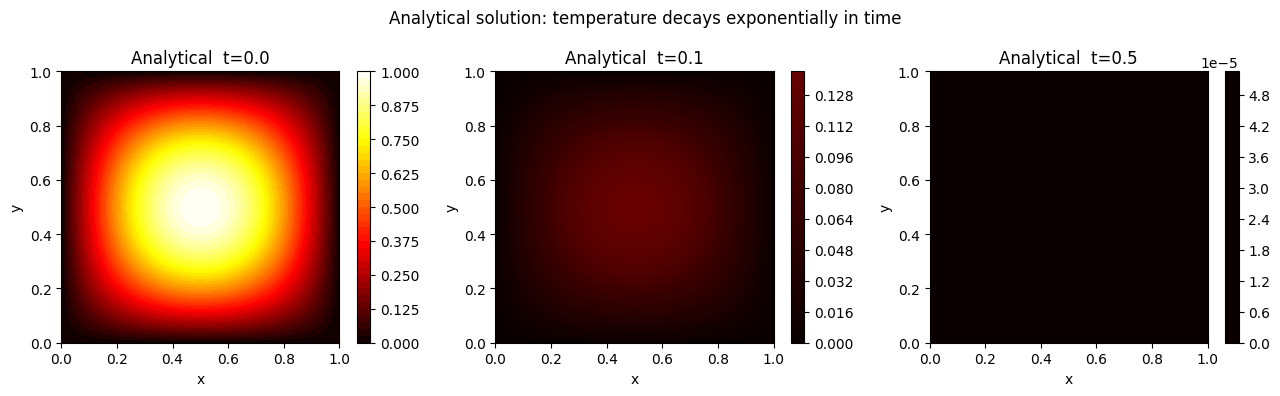

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── constants ────────────────────────────────────────────────────────────────
ALPHA = 1.0   # thermal diffusivity
T_END = 0.5   # simulate up to this time


def u_exact(x, y, t, alpha=ALPHA):
    """Analytical solution — works with numpy arrays or torch tensors."""
    if isinstance(x, np.ndarray):
        sin, exp = np.sin, np.exp
    else:
        sin, exp = torch.sin, torch.exp
    return sin(np.pi * x) * sin(np.pi * y) * exp(-2 * np.pi**2 * alpha * t)


# ── quick sanity check: plot the field at three time snapshots ───────────────
nx, ny = 60, 60
x1d = np.linspace(0, 1, nx)
y1d = np.linspace(0, 1, ny)
XX, YY = np.meshgrid(x1d, y1d)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, t_val in zip(axes, [0.0, 0.1, 0.5]):
    Z = u_exact(XX, YY, t_val)
    im = ax.contourf(XX, YY, Z, levels=40, cmap='hot', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Analytical  t={t_val}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('Analytical solution: temperature decays exponentially in time')
plt.tight_layout()
plt.show()

---
## 3. Point Sampling

A PINN has **no fixed grid**. Instead we randomly sample three sets of training points:

| Set | Where | Label |
|---|---|---|
| Interior (PDE) | random $(x,y,t) \in \Omega \times [0,T]$ | no label — just enforce residual = 0 |
| Initial condition | random $(x,y)$ at $t=0$ | $u = \sin(\pi x)\sin(\pi y)$ |
| Boundary | random points on 4 edges, any $t$ | $u = 0$ |

Resampling every epoch acts as a form of regularisation — the network never memorises specific points.

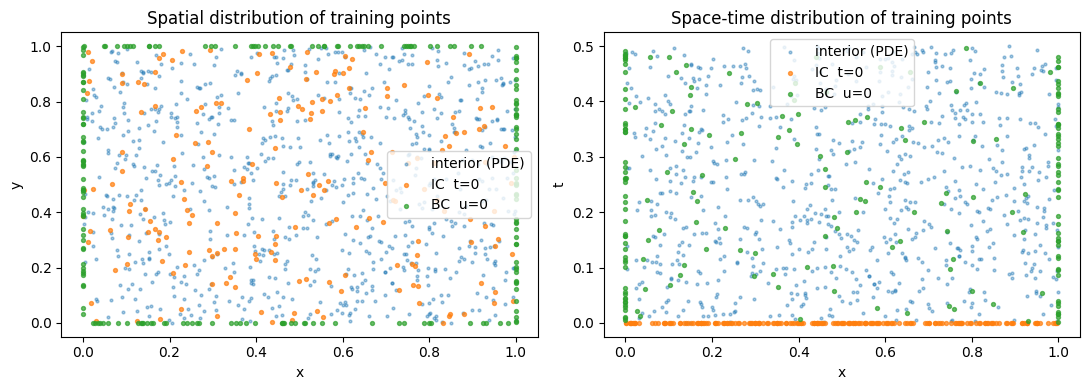

In [2]:
def sample_interior(n):
    """Random (x, y, t) inside the domain. No labels — used for PDE residual."""
    x = torch.rand(n)
    y = torch.rand(n)
    t = torch.rand(n) * T_END
    return x, y, t


def sample_ic(n):
    """Random (x, y) at t=0 with known u from the IC."""
    x = torch.rand(n)
    y = torch.rand(n)
    t = torch.zeros(n)
    u = torch.sin(torch.pi * x) * torch.sin(torch.pi * y)
    return x, y, t, u


def sample_bc(n):
    """Random points on the 4 edges of [0,1]^2, at random times. u=0 there."""
    n4 = n // 4
    t  = torch.rand(n) * T_END

    # bottom (y=0), top (y=1), left (x=0), right (x=1)
    x = torch.cat([
        torch.rand(n4),          # bottom
        torch.rand(n4),          # top
        torch.zeros(n4),         # left
        torch.ones(n4),          # right
    ])
    y = torch.cat([
        torch.zeros(n4),         # bottom
        torch.ones(n4),          # top
        torch.rand(n4),          # left
        torch.rand(n4),          # right
    ])
    u = torch.zeros(n)
    return x, y, t, u


# ── visualise the sampling ───────────────────────────────────────────────────
xi, yi, ti          = sample_interior(800)
xic, yic, tic, uic  = sample_ic(200)
xbc, ybc, tbc, ubc  = sample_bc(200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# spatial view (x vs y)
axes[0].scatter(xi,  yi,  s=4, alpha=0.4, label='interior (PDE)')
axes[0].scatter(xic, yic, s=8, alpha=0.7, label='IC  t=0')
axes[0].scatter(xbc, ybc, s=8, alpha=0.7, label='BC  u=0')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Spatial distribution of training points')
axes[0].legend()

# space-time view (x vs t)
axes[1].scatter(xi,  ti,  s=4, alpha=0.4, label='interior (PDE)')
axes[1].scatter(xic, tic, s=8, alpha=0.7, label='IC  t=0')
axes[1].scatter(xbc, tbc, s=8, alpha=0.7, label='BC  u=0')
axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
axes[1].set_title('Space-time distribution of training points')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Neural Network

A simple fully-connected (feed-forward) network:

$$\hat{u}_\theta : (x, y, t) \xrightarrow{\text{MLP}} u$$

**Architecture choices:**
- Input: 3 neurons $(x, y, t)$
- Output: 1 neuron $\hat{u}$
- Hidden layers: configurable (default 4 × 64)
- Activation: **Tanh** — infinitely differentiable, so autograd can compute $u_{xx}$, $u_{yy}$, $u_t$

> **Why not ReLU?** ReLU's second derivative is zero almost everywhere — it would make the PDE loss meaningless.

In [3]:
import torch.nn as nn


class PINN(nn.Module):
    def __init__(self, hidden=[64, 64, 64, 64]):
        super().__init__()
        dims = [3] + hidden + [1]          # 3 inputs → ... → 1 output
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:          # no activation after last layer
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

    def forward(self, x, y, t):
        inp = torch.stack([x, y, t], dim=1)   # shape [N, 3]
        return self.net(inp).squeeze(-1)       # shape [N]


# ── quick check ──────────────────────────────────────────────────────────────
model = PINN()
x_test = torch.rand(5)
y_test = torch.rand(5)
t_test = torch.rand(5)
out = model(x_test, y_test, t_test)
print('Input  shape:', x_test.shape)
print('Output shape:', out.shape)
print('Param count: ', sum(p.numel() for p in model.parameters()))

Input  shape: torch.Size([5])
Output shape: torch.Size([5])
Param count:  12801


---
## 5. Loss Functions

The total loss is a weighted sum of three terms:

$$\mathcal{L} = w_{\text{pde}}\,\mathcal{L}_{\text{pde}} + w_{\text{ic}}\,\mathcal{L}_{\text{ic}} + w_{\text{bc}}\,\mathcal{L}_{\text{bc}}$$

### PDE loss — enforces the heat equation at random interior points

$$\mathcal{L}_{\text{pde}} = \frac{1}{N_f}\sum_i \left(\hat{u}_t - \alpha(\hat{u}_{xx} + \hat{u}_{yy})\right)^2$$

Derivatives $\hat{u}_t$, $\hat{u}_{xx}$, $\hat{u}_{yy}$ are all computed with `torch.autograd.grad` — **no finite differences**.

### IC loss — pins the solution at $t=0$

$$\mathcal{L}_{\text{ic}} = \frac{1}{N_{ic}}\sum_i \left(\hat{u}(x_i, y_i, 0) - \sin(\pi x_i)\sin(\pi y_i)\right)^2$$

### BC loss — enforces $u=0$ on the boundary

$$\mathcal{L}_{\text{bc}} = \frac{1}{N_{bc}}\sum_i \hat{u}(x_b, y_b, t_b)^2$$

In [4]:
def pde_loss(model, x, y, t, alpha=ALPHA):
    """
    Compute the PDE residual at interior points.
    
    We need x, y, t to participate in the autograd graph so we can
    differentiate the network output with respect to them.
    """
    # Tell autograd we want gradients w.r.t. inputs
    x = x.clone().requires_grad_(True)
    y = y.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)

    u = model(x, y, t)               # forward pass
    ones = torch.ones_like(u)         # needed as grad_outputs for scalar reduction

    # First-order derivatives
    u_t = torch.autograd.grad(u, t,  grad_outputs=ones, create_graph=True)[0]
    u_x = torch.autograd.grad(u, x,  grad_outputs=ones, create_graph=True)[0]
    u_y = torch.autograd.grad(u, y,  grad_outputs=ones, create_graph=True)[0]

    # Second-order derivatives  (create_graph=True so backward through these works)
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=ones, create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=ones, create_graph=True)[0]

    residual = u_t - alpha * (u_xx + u_yy)
    return (residual ** 2).mean()


def ic_loss(model, x, y, t, u_target):
    """MSE between network prediction at t=0 and the prescribed IC."""
    u_pred = model(x, y, t)
    return ((u_pred - u_target) ** 2).mean()


def bc_loss(model, x, y, t):
    """MSE of network prediction on boundary (target is 0)."""
    u_pred = model(x, y, t)
    return (u_pred ** 2).mean()


# ── sanity check: untrained network losses ───────────────────────────────────
with torch.no_grad():
    pass  # bc_loss and ic_loss don't need grad here

xf, yf, tf           = sample_interior(500)
xi, yi, ti_, ui      = sample_ic(200)
xb, yb, tb, _        = sample_bc(200)

l_pde = pde_loss(model, xf, yf, tf)
l_ic  = ic_loss(model, xi, yi, ti_, ui)
l_bc  = bc_loss(model, xb, yb, tb)

print(f'Before training:')
print(f'  PDE loss : {l_pde.item():.4e}')
print(f'  IC  loss : {l_ic.item():.4e}')
print(f'  BC  loss : {l_bc.item():.4e}')

Before training:
  PDE loss : 1.3252e-04
  IC  loss : 2.2749e-01
  BC  loss : 4.5889e-03


---
## 6. Training

**Optimizer:** Adam (adaptive learning rate — good default for PINNs).

**Loss weights:** IC and BC are given higher weight than the PDE loss initially. This anchors the network to the correct boundary values before it tries to satisfy the PDE in the interior — a common trick to stabilise PINN training.

**Resampling:** We draw fresh random points every epoch. This prevents overfitting to a fixed set of collocation points.

In [5]:
# ── hyperparameters ───────────────────────────────────────────────────────────
N_PDE    = 2000    # interior collocation points per epoch
N_IC     = 500     # initial condition points per epoch
N_BC     = 500     # boundary condition points per epoch

W_PDE    = 1.0     # weight for PDE loss
W_IC     = 1.0    # weight for IC loss  — higher: anchor solution at t=0
W_BC     = 1.0    # weight for BC loss  — higher: anchor boundary values

EPOCHS   = 5000
LR       = 1e-3

# ── fresh model + optimiser ───────────────────────────────────────────────────
model     = PINN(hidden=[64, 64, 64, 64])
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {'pde': [], 'ic': [], 'bc': [], 'total': []}

# ── training loop ─────────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    # sample fresh points each epoch
    xf, yf, tf       = sample_interior(N_PDE)
    xi, yi, ti_, ui  = sample_ic(N_IC)
    xb, yb, tb, _    = sample_bc(N_BC)

    l_pde = pde_loss(model, xf, yf, tf)
    l_ic  = ic_loss(model, xi, yi, ti_, ui)
    l_bc  = bc_loss(model, xb, yb, tb)

    loss = W_PDE * l_pde + W_IC * l_ic + W_BC * l_bc
    loss.backward()
    optimizer.step()

    history['pde'].append(l_pde.item())
    history['ic'].append(l_ic.item())
    history['bc'].append(l_bc.item())
    history['total'].append(loss.item())

    if epoch % 500 == 0 or epoch == 1:
        print(f'Epoch {epoch:5d} | '
              f'total={loss.item():.3e} | '
              f'pde={l_pde.item():.3e} | '
              f'ic={l_ic.item():.3e} | '
              f'bc={l_bc.item():.3e}')

print('\nTraining complete.')

Epoch     1 | total=1.934e-01 | pde=8.425e-04 | ic=1.857e-01 | bc=6.864e-03
Epoch   500 | total=7.775e-02 | pde=4.046e-03 | ic=5.970e-02 | bc=1.401e-02
Epoch  1000 | total=2.319e-02 | pde=1.013e-02 | ic=1.127e-02 | bc=1.788e-03
Epoch  1500 | total=9.418e-03 | pde=2.850e-03 | ic=4.930e-03 | bc=1.639e-03
Epoch  2000 | total=8.247e-03 | pde=2.044e-03 | ic=4.662e-03 | bc=1.541e-03
Epoch  2500 | total=6.813e-03 | pde=2.351e-03 | ic=3.281e-03 | bc=1.181e-03
Epoch  3000 | total=5.019e-03 | pde=1.390e-03 | ic=2.768e-03 | bc=8.614e-04
Epoch  3500 | total=4.601e-03 | pde=1.533e-03 | ic=2.239e-03 | bc=8.294e-04
Epoch  4000 | total=3.688e-03 | pde=1.193e-03 | ic=1.733e-03 | bc=7.627e-04
Epoch  4500 | total=2.580e-03 | pde=7.301e-04 | ic=1.196e-03 | bc=6.532e-04
Epoch  5000 | total=4.799e-03 | pde=2.696e-03 | ic=1.514e-03 | bc=5.885e-04

Training complete.


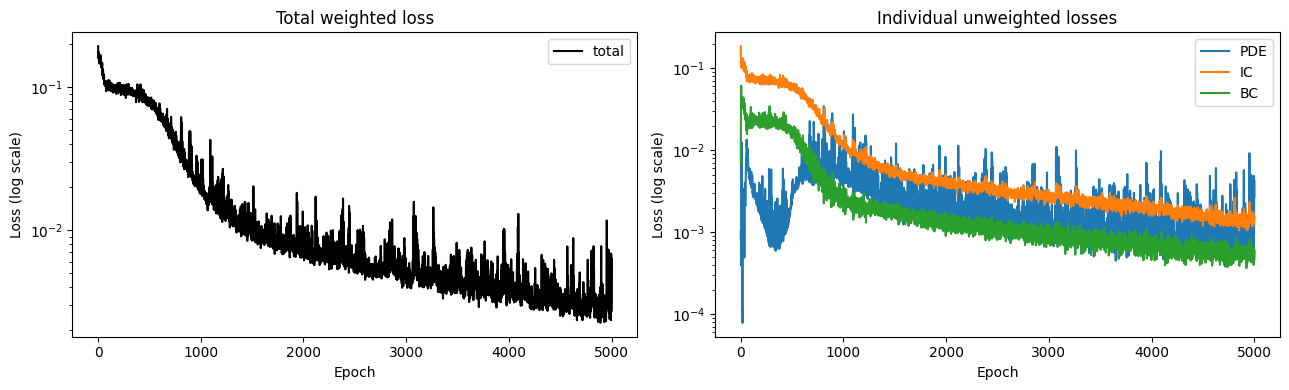

Final loss breakdown (unweighted):
  PDE : 2.6957e-03  ← still the dominant term
  IC  : 1.5145e-03
  BC  : 5.8851e-04


In [6]:
# ── plot loss curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].semilogy(epochs_range, history['total'], label='total', color='black')
axes[0].set_title('Total weighted loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (log scale)')
axes[0].legend()

axes[1].semilogy(epochs_range, history['pde'], label='PDE')
axes[1].semilogy(epochs_range, history['ic'],  label='IC')
axes[1].semilogy(epochs_range, history['bc'],  label='BC')
axes[1].set_title('Individual unweighted losses')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── print final loss breakdown ────────────────────────────────────────────────
print('Final loss breakdown (unweighted):')
print(f'  PDE : {history["pde"][-1]:.4e}  ← still the dominant term')
print(f'  IC  : {history["ic"][-1]:.4e}')
print(f'  BC  : {history["bc"][-1]:.4e}')


---
## 7. Evaluation

We compare the trained PINN against the analytical solution at several time snapshots.

**Metrics:**
- Visual: side-by-side heatmaps of analytical / PINN / absolute error
- Quantitative: relative $L_2$ error

$$\text{rel. } L_2 = \frac{\|\hat{u} - u_{\text{exact}}\|_2}{\|u_{\text{exact}}\|_2}$$

---
## 7b. Diagnosing Training Failure

Even though the *total weighted* loss looks small, the **individual losses tell a different story**.

From the training output above you can observe two things:

### Observation 1 — PDE loss starts suspiciously low, then rises

```
Epoch     1 | pde=9.8e-05   ← near zero at init
Epoch   500 | pde=4.4e-02   ← spikes as IC/BC start being satisfied
Epoch  5000 | pde=2.3e-03   ← still ~30× larger than IC and BC losses
```

**Why does PDE loss start near zero?** A randomly initialised Tanh network outputs values near zero with near-zero gradients everywhere. So $u_t \approx 0$, $u_{xx} \approx 0$, $u_{yy} \approx 0$ — the residual is accidentally small. As the network learns to match the IC (output $\sin(\pi x)\sin(\pi y)$), its derivatives become non-trivial and the PDE residual increases. It then slowly decreases as the physics is learned.

### Observation 2 — The weighted loss hides the real problem

With `W_IC=10, W_BC=10, W_PDE=1`:

$$\mathcal{L} = \underbrace{1 \times 2.3 \times 10^{-3}}_{\text{PDE}} + \underbrace{10 \times 8.2 \times 10^{-5}}_{\text{IC}} + \underbrace{10 \times 7.9 \times 10^{-5}}_{\text{BC}} \approx 3.9 \times 10^{-3}$$

The PDE term contributes ~60% of the total loss despite having the lowest weight. The IC and BC look well-converged, but the network hasn't learned to satisfy the heat equation in the interior.

**This is what causes the evaluation mismatch:** the network has memorised the initial and boundary conditions but the interior dynamics (the PDE) are not accurately captured.

### Fix: more epochs + learning rate schedule

Adam at a fixed LR will stall. Two practical improvements:
1. **Train longer** with a **cosine annealing** or **step LR decay**
2. **Switch to L-BFGS** for fine-tuning after Adam — L-BFGS is a second-order method that handles stiff problems much better, and is the standard in PINN literature


In [7]:
# ── Fix: Adam with cosine LR decay, then L-BFGS fine-tuning ──────────────────

EPOCHS_ADAM  = 8000
EPOCHS_LBFGS = 500    # L-BFGS steps (each does multiple line-search evals)

model2    = PINN(hidden=[64, 64, 64, 64])
optimizer_adam = torch.optim.Adam(model2.parameters(), lr=1e-3)

# cosine annealing: LR starts at 1e-3 and decays smoothly to 1e-5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_adam, T_max=EPOCHS_ADAM, eta_min=1e-5
)

history2 = {'pde': [], 'ic': [], 'bc': [], 'total': []}

print('── Phase 1: Adam with cosine LR decay ──────────────────────────')
for epoch in range(1, EPOCHS_ADAM + 1):
    optimizer_adam.zero_grad()

    xf, yf, tf       = sample_interior(N_PDE)
    xi, yi, ti_, ui  = sample_ic(N_IC)
    xb, yb, tb, _    = sample_bc(N_BC)

    l_pde = pde_loss(model2, xf, yf, tf)
    l_ic  = ic_loss(model2, xi, yi, ti_, ui)
    l_bc  = bc_loss(model2, xb, yb, tb)

    loss = W_PDE * l_pde + W_IC * l_ic + W_BC * l_bc
    loss.backward()
    optimizer_adam.step()
    scheduler.step()

    history2['pde'].append(l_pde.item())
    history2['ic'].append(l_ic.item())
    history2['bc'].append(l_bc.item())
    history2['total'].append(loss.item())

    if epoch % 2000 == 0 or epoch == 1:
        print(f'  Epoch {epoch:5d} | lr={scheduler.get_last_lr()[0]:.2e} | '
              f'pde={l_pde.item():.3e} | ic={l_ic.item():.3e} | bc={l_bc.item():.3e}')

# ── Phase 2: L-BFGS fine-tuning ───────────────────────────────────────────────
# L-BFGS requires a closure: a callable that recomputes the loss each line-search step.
# We fix the sample points for this phase so the closure is well-defined.
print('\n── Phase 2: L-BFGS fine-tuning ────────────────────────────────')

xf_fix, yf_fix, tf_fix  = sample_interior(N_PDE)
xi_fix, yi_fix, ti_fix, ui_fix = sample_ic(N_IC)
xb_fix, yb_fix, tb_fix, _ = sample_bc(N_BC)

optimizer_lbfgs = torch.optim.LBFGS(
    model2.parameters(),
    lr=1.0,
    max_iter=20,           # line-search iterations per step
    history_size=50,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    line_search_fn='strong_wolfe',
)

lbfgs_losses = []

def closure():
    optimizer_lbfgs.zero_grad()
    l_pde = pde_loss(model2, xf_fix, yf_fix, tf_fix)
    l_ic  = ic_loss(model2, xi_fix, yi_fix, ti_fix, ui_fix)
    l_bc  = bc_loss(model2, xb_fix, yb_fix, tb_fix)
    loss  = W_PDE * l_pde + W_IC * l_ic + W_BC * l_bc
    loss.backward()
    lbfgs_losses.append(loss.item())
    return loss

for step in range(EPOCHS_LBFGS):
    optimizer_lbfgs.step(closure)
    if (step + 1) % 100 == 0:
        print(f'  L-BFGS step {step+1:4d} | loss={lbfgs_losses[-1]:.3e}')

print('\nFine-tuning complete.')


── Phase 1: Adam with cosine LR decay ──────────────────────────
  Epoch     1 | lr=1.00e-03 | pde=8.921e-04 | ic=3.487e-01 | bc=8.288e-03
  Epoch  2000 | lr=8.55e-04 | pde=2.624e-03 | ic=5.350e-03 | bc=1.483e-03
  Epoch  4000 | lr=5.05e-04 | pde=2.173e-03 | ic=3.698e-03 | bc=1.160e-03
  Epoch  6000 | lr=1.55e-04 | pde=6.425e-04 | ic=3.033e-03 | bc=1.167e-03
  Epoch  8000 | lr=1.00e-05 | pde=1.034e-03 | ic=2.780e-03 | bc=9.089e-04

── Phase 2: L-BFGS fine-tuning ────────────────────────────────
  L-BFGS step  100 | loss=2.378e-05
  L-BFGS step  200 | loss=4.357e-06
  L-BFGS step  300 | loss=4.357e-06
  L-BFGS step  400 | loss=4.357e-06
  L-BFGS step  500 | loss=4.357e-06

Fine-tuning complete.


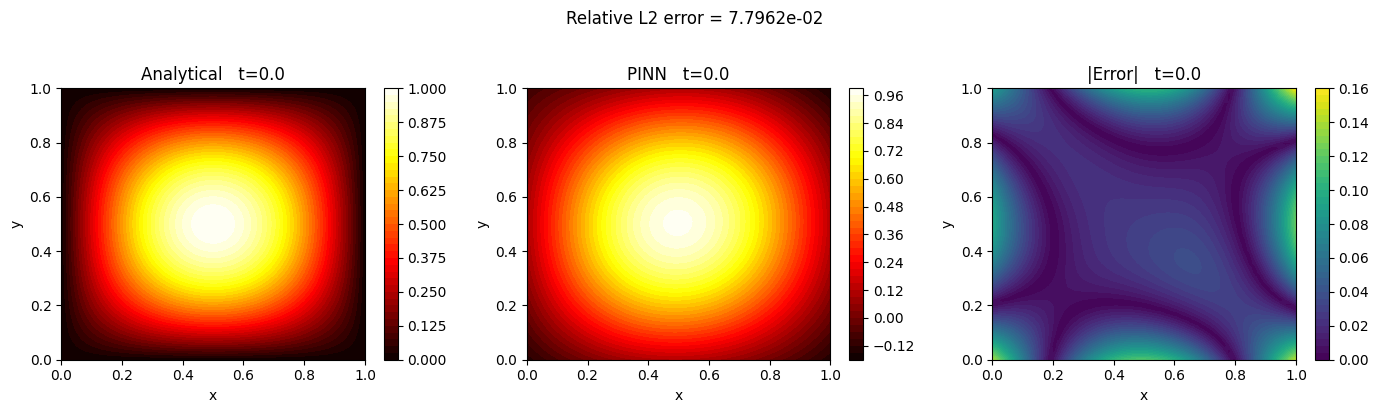

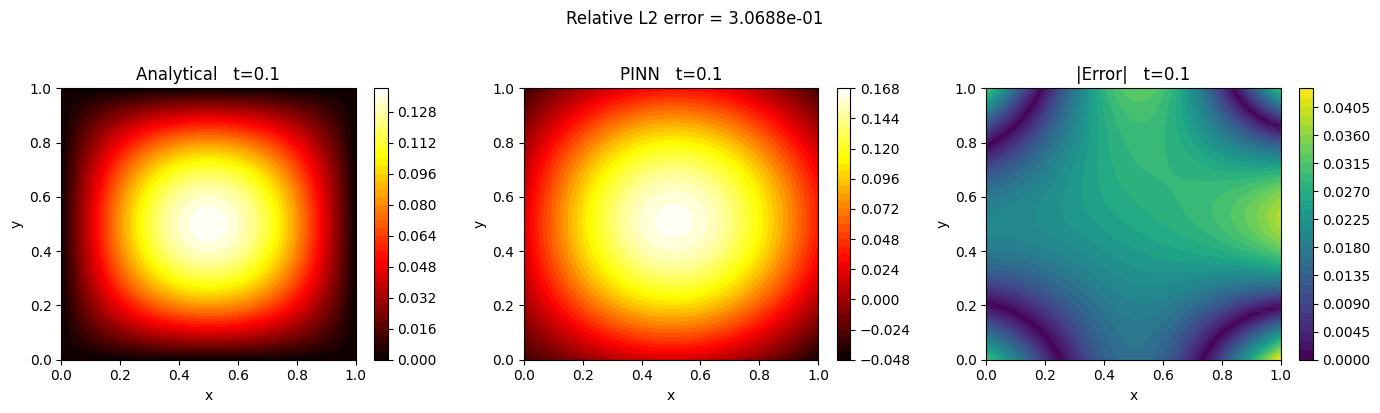

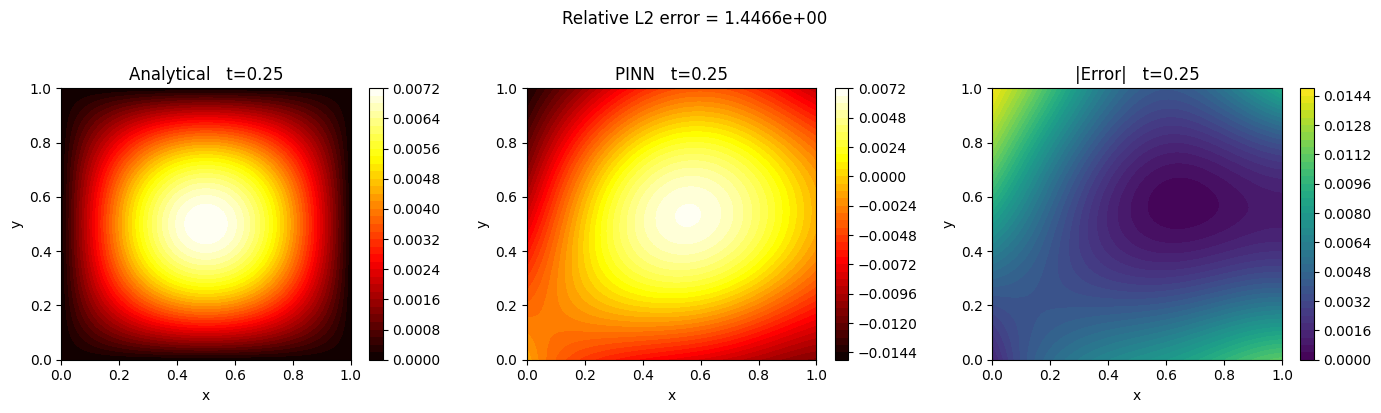

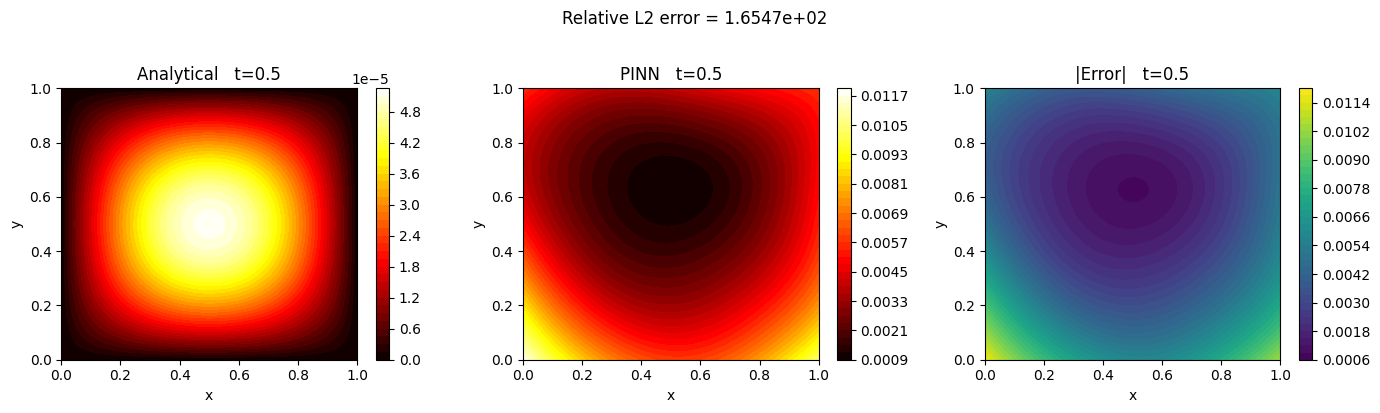

In [8]:
def evaluate_at_time(model, t_val, nx=60, ny=60):
    """Plot analytical vs PINN vs error at a fixed time t_val."""
    x1d = np.linspace(0, 1, nx)
    y1d = np.linspace(0, 1, ny)
    XX, YY = np.meshgrid(x1d, y1d)

    # analytical (numpy)
    u_true = u_exact(XX, YY, t_val)

    # PINN prediction (torch → numpy)
    x_t = torch.tensor(XX.ravel(), dtype=torch.float32)
    y_t = torch.tensor(YY.ravel(), dtype=torch.float32)
    t_t = torch.full_like(x_t, t_val)

    model.eval()
    with torch.no_grad():
        u_pred = model(x_t, y_t, t_t).numpy().reshape(ny, nx)
    model.train()

    err = np.abs(u_pred - u_true)
    rel_l2 = np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, title, cmap in zip(
        axes,
        [u_true, u_pred, err],
        ['Analytical', 'PINN', '|Error|'],
        ['hot', 'hot', 'viridis'],
    ):
        im = ax.contourf(XX, YY, data, levels=40, cmap=cmap)
        plt.colorbar(im, ax=ax)
        ax.set_title(f'{title}   t={t_val}')
        ax.set_xlabel('x'); ax.set_ylabel('y')

    plt.suptitle(f'Relative L2 error = {rel_l2:.4e}', y=1.02)
    plt.tight_layout()
    plt.show()
    return rel_l2


# ── evaluate at multiple time snapshots ───────────────────────────────────────
t_snapshots = [0.0, 0.1, 0.25, 0.5]
errors = {}
for t_val in t_snapshots:
    errors[t_val] = evaluate_at_time(model, t_val)

In [ ]:
# ── aggregate error summary ───────────────────────────────────────────────────
print('Relative L2 error by time snapshot:')
print('-' * 35)
for t_val, err in errors.items():
    bar = '█' * int(err * 1000)
    print(f'  t={t_val:.2f}  |  {err:.4e}  {bar}')

print(f'\nMean relative L2 error: {np.mean(list(errors.values())):.4e}')

---
## Next Steps

Once this baseline works, natural extensions to explore:

| Extension | What changes |
|---|---|
| **Steady-state heat** | Drop the $\partial u/\partial t$ term, solve $\nabla^2 u = 0$ (or with source) |
| **Non-zero BCs** | Change the BC loss target from 0 to some $g(x,y,t)$ |
| **Triangle mesh domain** | Replace unit-square sampler with points sampled inside a mesh |
| **Multi-scale / zoom** | Add a scale parameter to the input; train at different resolutions |
| **LBFGS fine-tuning** | Switch optimiser after Adam convergence for tighter residuals |

---
## 8. Mesh-Based Sampling Infrastructure

So far we've sampled from a unit square using `torch.rand()` — trivial because the geometry is a box.
For a **triangle mesh** we need a proper sampler that works on arbitrary shapes.

### Two things we need to sample

| What | Where | How |
|---|---|---|
| Interior (PDE) collocation points | inside the triangles | barycentric coordinates |
| Boundary (BC) points | on boundary edge segments | linear interpolation along each edge |

### Barycentric coordinates

Any point $P$ inside a triangle with vertices $v_0, v_1, v_2$ can be written as:

$$P = (1 - r_1 - r_2)\,v_0 + r_1\,v_1 + r_2\,v_2 \quad \text{where } r_1, r_2 \geq 0,\; r_1+r_2 \leq 1$$

To sample uniformly in a triangle, draw $r_1, r_2 \sim U(0,1)$ and **fold back** any point with $r_1 + r_2 > 1$ by reflecting: $(r_1, r_2) \to (1-r_1, 1-r_2)$.

### Boundary condition data structure

Each boundary edge needs to know:
1. Which two vertices define it
2. What $u$ value to enforce there (a function of position, not just a scalar)

```python
boundary_edges = [
    {'v0': 0, 'v1': 1, 'bc': lambda x, y: np.sin(np.pi * x)},  # hot
    {'v0': 1, 'v1': 2, 'bc': lambda x, y: np.zeros(len(x))},    # cold
    ...
]
```

This makes it easy to assign **different BCs to different edges** — essential for the L-shape.


In [9]:
def triangle_areas(vertices, triangles):
    """Area of each triangle using the cross-product formula."""
    v0 = vertices[triangles[:, 0]]
    v1 = vertices[triangles[:, 1]]
    v2 = vertices[triangles[:, 2]]
    # 0.5 * |cross(v1-v0, v2-v0)|
    cross = (v1[:, 0] - v0[:, 0]) * (v2[:, 1] - v0[:, 1]) \
          - (v1[:, 1] - v0[:, 1]) * (v2[:, 0] - v0[:, 0])
    return 0.5 * np.abs(cross)


def sample_from_mesh(vertices, triangles, n):
    """
    Sample n points uniformly inside a triangle mesh.

    Steps:
      1. Pick a triangle at random, weighted by area (larger triangles get more points).
      2. Sample a random barycentric point inside that triangle.
    """
    areas = triangle_areas(vertices, triangles)
    probs = areas / areas.sum()                              # normalise to probability
    chosen = np.random.choice(len(triangles), size=n, p=probs)

    r1 = np.random.rand(n)
    r2 = np.random.rand(n)

    # Fold back points outside the triangle (r1+r2 > 1)
    mask = r1 + r2 > 1
    r1[mask] = 1.0 - r1[mask]
    r2[mask] = 1.0 - r2[mask]

    v0 = vertices[triangles[chosen, 0]]   # shape [n, 2]
    v1 = vertices[triangles[chosen, 1]]
    v2 = vertices[triangles[chosen, 2]]

    x = (1 - r1 - r2) * v0[:, 0] + r1 * v1[:, 0] + r2 * v2[:, 0]
    y = (1 - r1 - r2) * v0[:, 1] + r1 * v1[:, 1] + r2 * v2[:, 1]
    return x.astype(np.float32), y.astype(np.float32)


def sample_bc_from_edges(vertices, boundary_edges, n_per_edge):
    """
    Sample n_per_edge points on each boundary edge segment.

    boundary_edges: list of dicts  {'v0': int, 'v1': int, 'bc': callable(x,y)->array}
    Returns: x, y, u  — all concatenated across edges.
    """
    xs, ys, us = [], [], []
    for edge in boundary_edges:
        p0 = vertices[edge['v0']]    # start vertex
        p1 = vertices[edge['v1']]    # end vertex
        t  = np.random.rand(n_per_edge)                  # parameter along edge
        x  = (p0[0] + t * (p1[0] - p0[0])).astype(np.float32)
        y  = (p0[1] + t * (p1[1] - p0[1])).astype(np.float32)
        u  = edge['bc'](x, y).astype(np.float32)
        xs.append(x); ys.append(y); us.append(u)
    return np.concatenate(xs), np.concatenate(ys), np.concatenate(us)


def plot_mesh(vertices, triangles, boundary_edges=None, title='Mesh'):
    """Visualise the triangle mesh and (optionally) colour-code boundary edges."""
    fig, ax = plt.subplots(figsize=(5, 5))
    # draw triangles
    for tri in triangles:
        pts = vertices[np.append(tri, tri[0])]   # close the loop
        ax.plot(pts[:, 0], pts[:, 1], 'k-', lw=0.8)

    ax.scatter(vertices[:, 0], vertices[:, 1], zorder=5, color='k', s=30)
    for i, (vx, vy) in enumerate(vertices):
        ax.annotate(f'v{i}', (vx, vy), textcoords='offset points', xytext=(4, 4), fontsize=8)

    # colour-code boundary edges
    if boundary_edges:
        colours = plt.cm.tab10(np.linspace(0, 1, len(boundary_edges)))
        for edge, col in zip(boundary_edges, colours):
            p0, p1 = vertices[edge['v0']], vertices[edge['v1']]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=4, alpha=0.7,
                    color=col, label=edge.get('label', ''))
        ax.legend(fontsize=7, loc='upper right')

    ax.set_aspect('equal'); ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout(); plt.show()


---
## 9. Validate: Unit Square as a Triangle Mesh

The unit square $[0,1]^2$ is split into **two triangles** along the diagonal.
The domain is identical to Section 11, so the PINN result must match the analytical solution — this is our **regression test** for the mesh sampling code.

```
v3 (0,1) -------- v2 (1,1)
   |      T1    /  |
   |          /    |
   |        /   T0 |
   |      /        |
v0 (0,0) -------- v1 (1,0)

T0: (v0, v1, v2)
T1: (v0, v2, v3)
```

Boundary edges (same BCs as Section 8):
- Bottom `v0→v1`: $u = \sin(\pi x)$ — hot
- Right  `v1→v2`: $u = 0$ — cold
- Top    `v2→v3`: $u = 0$ — cold
- Left   `v3→v0`: $u = 0$ — cold


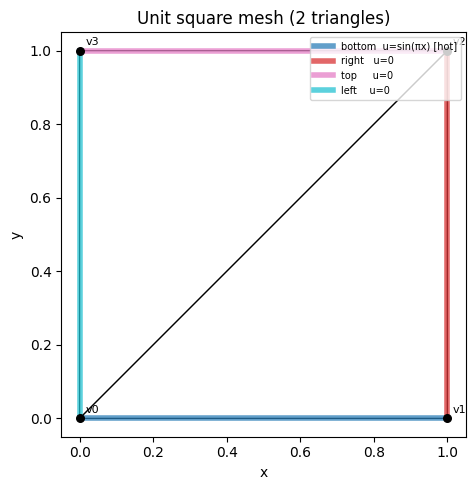

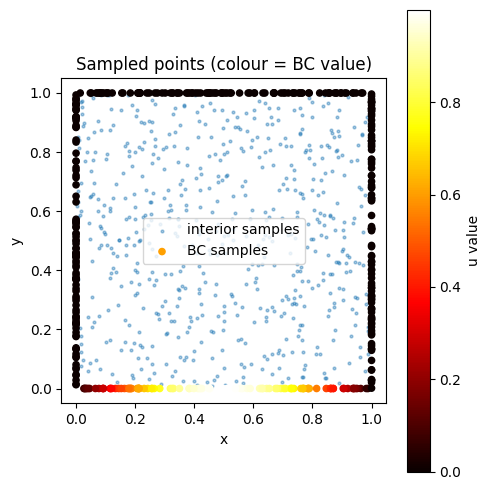

Total interior points: 600
Total boundary points: 400  (4 edges × 100)
BC value range: [0.000, 1.000]


In [10]:
# ── Define unit square mesh ───────────────────────────────────────────────────
cold = lambda x, y: np.zeros(len(x), dtype=np.float32)
hot  = lambda x, y: np.sin(np.pi * x).astype(np.float32)

sq_vertices = np.array([
    [0., 0.],   # v0
    [1., 0.],   # v1
    [1., 1.],   # v2
    [0., 1.],   # v3
], dtype=np.float32)

sq_triangles = np.array([
    [0, 1, 2],  # T0: lower-right triangle
    [0, 2, 3],  # T1: upper-left triangle
])

sq_boundary = [
    {'v0': 0, 'v1': 1, 'bc': hot,  'label': 'bottom  u=sin(πx) [hot]'},
    {'v0': 1, 'v1': 2, 'bc': cold, 'label': 'right   u=0'},
    {'v0': 2, 'v1': 3, 'bc': cold, 'label': 'top     u=0'},
    {'v0': 3, 'v1': 0, 'bc': cold, 'label': 'left    u=0'},
]

plot_mesh(sq_vertices, sq_triangles, sq_boundary, title='Unit square mesh (2 triangles)')

# ── Verify sampler: scatter interior + boundary points ────────────────────────
xi, yi = sample_from_mesh(sq_vertices, sq_triangles, 600)
xb, yb, ub = sample_bc_from_edges(sq_vertices, sq_boundary, n_per_edge=100)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(xi, yi, s=4, alpha=0.4, label='interior samples')
sc = ax.scatter(xb, yb, c=ub, cmap='hot', s=20, zorder=5, label='BC samples')
plt.colorbar(sc, ax=ax, label='u value')
ax.set_aspect('equal')
ax.set_title('Sampled points (colour = BC value)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout(); plt.show()

print(f'Total interior points: {len(xi)}')
print(f'Total boundary points: {len(xb)}  ({len(sq_boundary)} edges × 100)')
print(f'BC value range: [{ub.min():.3f}, {ub.max():.3f}]')


In [11]:
# ── Train steady-state PINN using mesh samplers ───────────────────────────────
# Identical architecture and losses to Section 8 — only the sampler changes.

model_sq = PINN_SS(hidden=[64, 64, 64, 64])
opt_sq   = torch.optim.Adam(model_sq.parameters(), lr=1e-3)
sched_sq = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sq, T_max=8000, eta_min=1e-5)

N_INT_SQ, N_PER_EDGE_SQ = 2000, 125    # 4 edges × 125 = 500 BC points

print('Training on unit-square mesh...')
for epoch in range(1, 8001):
    opt_sq.zero_grad()

    # ── interior: mesh-based barycentric sampling ──────────────────────────
    xi_np, yi_np = sample_from_mesh(sq_vertices, sq_triangles, N_INT_SQ)
    xf = torch.from_numpy(xi_np)
    yf = torch.from_numpy(yi_np)

    # ── boundary: per-edge sampling ────────────────────────────────────────
    xb_np, yb_np, ub_np = sample_bc_from_edges(sq_vertices, sq_boundary, N_PER_EDGE_SQ)
    xb = torch.from_numpy(xb_np)
    yb = torch.from_numpy(yb_np)
    ub = torch.from_numpy(ub_np)

    l_pde = pde_loss_ss(model_sq, xf, yf)
    l_bc  = bc_loss_ss(model_sq, xb, yb, ub)
    loss  = W_PDE_SS * l_pde + W_BC_SS * l_bc

    loss.backward()
    opt_sq.step()
    sched_sq.step()

    if epoch % 2000 == 0 or epoch == 1:
        print(f'  Epoch {epoch:5d} | pde={l_pde.item():.3e} | bc={l_bc.item():.3e}')

print('Done.')


NameError: name 'PINN_SS' is not defined

In [ ]:
# ── Evaluate: mesh-sampled PINN vs analytical on the same grid ───────────────
x1d = np.linspace(0, 1, 80)
y1d = np.linspace(0, 1, 80)
XX, YY = np.meshgrid(x1d, y1d)

u_true = u_exact_steady(XX, YY)

x_t = torch.tensor(XX.ravel(), dtype=torch.float32)
y_t = torch.tensor(YY.ravel(), dtype=torch.float32)

model_sq.eval()
with torch.no_grad():
    u_pred_sq = model_sq(x_t, y_t).numpy().reshape(80, 80)
model_sq.train()

err_sq   = np.abs(u_pred_sq - u_true)
rel_l2   = np.linalg.norm(u_pred_sq - u_true) / np.linalg.norm(u_true)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title, cmap in zip(
    axes,
    [u_true, u_pred_sq, err_sq],
    ['Analytical', 'PINN (mesh sampler)', '|Error|'],
    ['hot', 'hot', 'viridis'],
):
    im = ax.contourf(XX, YY, data, levels=40, cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'Unit square mesh validation  |  Relative L2 = {rel_l2:.4e}', y=1.02)
plt.tight_layout()
plt.show()

print('If relative L2 is similar to Section 8 (same domain), the mesh sampler is correct.')


---
## 10. L-Shaped Domain

The L-shape is the classic test case for PDE solvers because it has a **re-entrant corner** — a 270° interior angle at (0.5, 0.5) — which creates a stress concentration and challenges any numerical method.

### Geometry

We take the unit square and remove the top-right quadrant:

```
(0,1)---(0.5,1)
  |   top  |
  |  rect  |
(0,0.5)--(0.5,0.5)--(1,0.5)
  |           bot right  |
  |     bottom rect      |
(0,0)--------------(1,0)
```

**Vertices:**

| Index | Coordinates | Role |
|---|---|---|
| v0 | (0, 0) | outer corner |
| v1 | (1, 0) | outer corner |
| v2 | (1, 0.5) | outer corner |
| v3 | (0.5, 0.5) | **re-entrant corner** |
| v4 | (0.5, 1) | outer corner |
| v5 | (0, 1) | outer corner |
| v6 | (0, 0.5) | interior vertex (needed for triangulation) |

**Triangulation (5 triangles):**
```
T0: (v0, v1, v2)  — right part of bottom rectangle
T1: (v0, v2, v3)  — left part of bottom rectangle, right half
T2: (v0, v3, v6)  — left part of bottom rectangle, left half
T3: (v6, v3, v4)  — top rectangle, lower triangle
T4: (v6, v4, v5)  — top rectangle, upper triangle
```

### Boundary Conditions

There are **7 boundary edge segments**. Each is independently assigned a BC:

| Edge | From → To | Condition | Reason |
|---|---|---|---|
| Bottom | v0 → v1 | $u = \sin(\pi x)$ | **hot** wall — drives the field |
| Right-outer | v1 → v2 | $u = 0$ | cold |
| Inner horiz. | v2 → v3 | $u = 0$ | cold — re-entrant inner edge |
| Inner vert. | v3 → v4 | $u = 0$ | cold — re-entrant inner edge |
| Top | v4 → v5 | $u = 0$ | cold |
| Left-upper | v5 → v6 | $u = 0$ | cold |
| Left-lower | v6 → v0 | $u = 0$ | cold |

> **Why careful BCs matter here:** the two inner edges (v2→v3 and v3→v4) meet at the re-entrant corner v3=(0.5,0.5). Both are cold, which is consistent. If you accidentally left these undefined, the PINN would have no constraint at the inner boundary and the solution would be wrong inside the top-right region. **Every edge segment must be explicitly labelled.**

### Reference solution

There is no clean analytical solution for this geometry. We compute a reference using **finite differences on a masked grid**: solve the Laplace equation on the full $100\times100$ grid, marking points in the top-right quadrant as "outside" and not including them in the system.


In [ ]:
# ── Define L-shape mesh ───────────────────────────────────────────────────────
L_vertices = np.array([
    [0.0, 0.0],   # v0
    [1.0, 0.0],   # v1
    [1.0, 0.5],   # v2
    [0.5, 0.5],   # v3  ← re-entrant corner
    [0.5, 1.0],   # v4
    [0.0, 1.0],   # v5
    [0.0, 0.5],   # v6  ← added to allow clean triangulation
], dtype=np.float32)

L_triangles = np.array([
    [0, 1, 2],   # T0: lower-right
    [0, 2, 3],   # T1: lower-middle
    [0, 3, 6],   # T2: lower-left
    [6, 3, 4],   # T3: upper-right of top rect
    [6, 4, 5],   # T4: upper-left of top rect
])

# Quick sanity check: total area should equal 0.75 (unit square minus top-right quadrant)
areas = triangle_areas(L_vertices, L_triangles)
print(f'Triangle areas: {areas}')
print(f'Total area: {areas.sum():.4f}  (expected 0.75)')

L_boundary = [
    {'v0': 0, 'v1': 1, 'bc': hot,  'label': 'bottom         u=sin(πx) [hot]'},
    {'v0': 1, 'v1': 2, 'bc': cold, 'label': 'right-outer    u=0'},
    {'v0': 2, 'v1': 3, 'bc': cold, 'label': 'inner-horiz    u=0 ← re-entrant'},
    {'v0': 3, 'v1': 4, 'bc': cold, 'label': 'inner-vert     u=0 ← re-entrant'},
    {'v0': 4, 'v1': 5, 'bc': cold, 'label': 'top            u=0'},
    {'v0': 5, 'v1': 6, 'bc': cold, 'label': 'left-upper     u=0'},
    {'v0': 6, 'v1': 0, 'bc': cold, 'label': 'left-lower     u=0'},
]

plot_mesh(L_vertices, L_triangles, L_boundary, title='L-shaped mesh (5 triangles, 7 boundary edges)')


In [ ]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def fd_reference_L(N=120):
    """
    Finite-difference reference solution for the Laplace equation on the L-shape.

    Grid: N×N on [0,1]^2.  Points where (x>0.5 AND y>0.5) are outside the domain.
    BCs:  bottom y=0 → u=sin(πx),  all other boundary edges → u=0.

    Returns: XX, YY (meshgrid), U (solution, NaN outside domain).
    """
    h = 1.0 / (N - 1)
    x1d = np.linspace(0, 1, N)
    y1d = np.linspace(0, 1, N)
    XX, YY = np.meshgrid(x1d, y1d)   # shape [N, N], YY[j,i] = y at row j

    # A point (i, j) is inside the L-shape if NOT (x>0.5 AND y>0.5)
    def inside(i, j):
        return not (x1d[i] > 0.5 + 1e-9 and y1d[j] > 0.5 + 1e-9)

    # Assign a linear index to each interior (unknown) point
    idx = np.full((N, N), -1, dtype=int)
    counter = 0
    for j in range(N):
        for i in range(N):
            if inside(i, j):
                idx[j, i] = counter
                counter += 1
    n_unknowns = counter

    A = lil_matrix((n_unknowns, n_unknowns))
    b = np.zeros(n_unknowns)

    for j in range(N):
        for i in range(N):
            if not inside(i, j):
                continue
            k = idx[j, i]   # this point's row in the linear system

            # ── boundary points: enforce BC directly ───────────────────────
            is_boundary = (i == 0 or i == N-1 or j == 0 or j == N-1
                           or (i == N//2 and y1d[j] > 0.5 - 1e-9)   # inner vert edge
                           or (j == N//2 and x1d[i] > 0.5 - 1e-9))  # inner horiz edge

            if is_boundary:
                A[k, k] = 1.0
                if j == 0:                      # bottom → hot
                    b[k] = np.sin(np.pi * x1d[i])
                else:                           # all other boundary → cold
                    b[k] = 0.0
            else:
                # ── interior: standard 5-point Laplace stencil ────────────
                # (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j]) / h^2 = 0
                A[k, k] = -4.0
                for di, dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                    ni, nj = i+di, j+dj
                    if inside(ni, nj):
                        A[k, idx[nj, ni]] = 1.0
                    # if neighbour is outside the L (only possible at re-entrant corner
                    # vicinity), treat it as a Dirichlet=0 boundary (already in b)

    u_vec = spsolve(A.tocsr(), b)

    U = np.full((N, N), np.nan)
    for j in range(N):
        for i in range(N):
            if inside(i, j):
                U[j, i] = u_vec[idx[j, i]]

    return XX, YY, U


print('Computing FD reference solution...')
XX_fd, YY_fd, U_fd = fd_reference_L(N=120)
print('Done.')

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.contourf(XX_fd, YY_fd, U_fd, levels=40, cmap='hot')
plt.colorbar(im, ax=ax)
ax.set_title('FD reference: L-shape Laplace\n(NaN = outside domain)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()


In [ ]:
# ── Train PINN on L-shape ─────────────────────────────────────────────────────
model_L  = PINN_SS(hidden=[64, 64, 64, 64])
opt_L    = torch.optim.Adam(model_L.parameters(), lr=1e-3)
sched_L  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_L, T_max=10000, eta_min=1e-5)

# More BC points per edge because we now have 7 edges instead of 4
N_INT_L, N_PER_EDGE_L = 3000, 150   # 7 × 150 = 1050 BC points

print('Training PINN on L-shape...')
for epoch in range(1, 10001):
    opt_L.zero_grad()

    xi_np, yi_np = sample_from_mesh(L_vertices, L_triangles, N_INT_L)
    xf = torch.from_numpy(xi_np)
    yf = torch.from_numpy(yi_np)

    xb_np, yb_np, ub_np = sample_bc_from_edges(L_vertices, L_boundary, N_PER_EDGE_L)
    xb = torch.from_numpy(xb_np)
    yb = torch.from_numpy(yb_np)
    ub = torch.from_numpy(ub_np)

    l_pde = pde_loss_ss(model_L, xf, yf)
    l_bc  = bc_loss_ss(model_L, xb, yb, ub)
    loss  = W_PDE_SS * l_pde + W_BC_SS * l_bc

    loss.backward()
    opt_L.step()
    sched_L.step()

    if epoch % 2000 == 0 or epoch == 1:
        print(f'  Epoch {epoch:5d} | pde={l_pde.item():.3e} | bc={l_bc.item():.3e}')

print('Done.')


In [ ]:
# ── Evaluate: PINN vs FD reference on the L-shape ────────────────────────────
# Query the PINN on the same grid as the FD solution.
# Points outside the L-shape are masked to NaN (same as FD).

N_eval = 120
x1d_e = np.linspace(0, 1, N_eval)
y1d_e = np.linspace(0, 1, N_eval)
XX_e, YY_e = np.meshgrid(x1d_e, y1d_e)

# Build a mask: True = inside L-shape
inside_mask = ~((XX_e > 0.5 + 1e-9) & (YY_e > 0.5 + 1e-9))

x_flat = XX_e[inside_mask].astype(np.float32)
y_flat = YY_e[inside_mask].astype(np.float32)

model_L.eval()
with torch.no_grad():
    u_flat = model_L(torch.from_numpy(x_flat), torch.from_numpy(y_flat)).numpy()
model_L.train()

U_pinn = np.full((N_eval, N_eval), np.nan)
U_pinn[inside_mask] = u_flat

# ── Error (only inside domain) ────────────────────────────────────────────────
err_L = np.abs(U_pinn - U_fd)
valid = inside_mask & ~np.isnan(U_fd)
rel_l2_L = (np.linalg.norm(U_pinn[valid] - U_fd[valid])
            / np.linalg.norm(U_fd[valid]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(
    axes,
    [U_fd, U_pinn, err_L],
    ['FD Reference', 'PINN', '|Error|'],
):
    im = ax.contourf(XX_e, YY_e, data, levels=40, cmap='hot')
    plt.colorbar(im, ax=ax)
    # draw the L-shape boundary
    bx = [0,1,1,0.5,0.5,0,0]
    by = [0,0,0.5,0.5,1,1,0]
    ax.plot(bx, by, 'w-', lw=1.5)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.suptitle(f'L-shape  |  Relative L2 vs FD = {rel_l2_L:.4e}', y=1.02)
plt.tight_layout()
plt.show()

print(f'Relative L2 error (PINN vs FD reference): {rel_l2_L:.4e}')
print()
print('Things to notice in the field:')
print('  - Heat plume rises from the bottom, decays toward the top')
print('  - The re-entrant corner at (0.5,0.5) creates a sharp gradient')
print('  - The top-right quadrant is empty (outside domain)')


---
## 11. Steady-State Heat Equation (Laplace)

When we remove the time derivative we get the **Laplace equation**:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

With all-zero BCs the only solution is $u=0$ — trivially boring. To get an interesting field we make one wall "hot":

| Wall | Condition |
|---|---|
| Bottom ($y=0$) | $u = \sin(\pi x)$ |
| Top ($y=1$) | $u = 0$ |
| Left ($x=0$) | $u = 0$ |
| Right ($x=1$) | $u = 0$ |

### Analytical solution

Using separation of variables with the bottom BC as the driving term:

$$\boxed{u(x, y) = \sin(\pi x)\,\frac{\sinh(\pi(1 - y))}{\sinh(\pi)}}$$

**Verification:**
- $u_{xx} = -\pi^2 \sin(\pi x)\frac{\sinh(\pi(1-y))}{\sinh(\pi)}$
- $u_{yy} = +\pi^2 \sin(\pi x)\frac{\sinh(\pi(1-y))}{\sinh(\pi)}$
- $u_{xx} + u_{yy} = 0$ ✓
- At $y=0$: $\sinh(\pi)/\sinh(\pi) = 1$, so $u = \sin(\pi x)$ ✓
- At $y=1$: $\sinh(0) = 0$, so $u = 0$ ✓
- At $x=0,1$: $\sin(0) = \sin(\pi) = 0$ ✓

The result is a "heat plume" shape — temperature is highest at the bottom-centre and decays smoothly toward zero at the top and sides.

> **Want something even richer?** Add a second non-zero wall, e.g. top $= \sin(2\pi x)$. By **superposition** (Laplace is linear), solve each non-zero wall independently and add the results. The two competing modes create a saddle-like interior field.


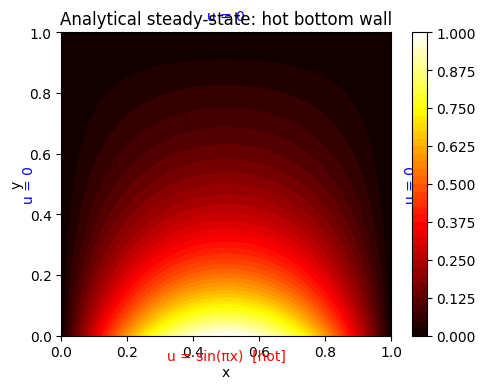

In [12]:
def u_exact_steady(x, y):
    """Analytical solution for the steady-state (Laplace) problem."""
    if isinstance(x, np.ndarray):
        sin, sinh = np.sin, np.sinh
    else:
        sin, sinh = torch.sin, torch.sinh
    return sin(np.pi * x) * sinh(np.pi * (1 - y)) / np.sinh(np.pi)


# ── visualise the analytical steady-state field ───────────────────────────────
x1d = np.linspace(0, 1, 80)
y1d = np.linspace(0, 1, 80)
XX, YY = np.meshgrid(x1d, y1d)

Z = u_exact_steady(XX, YY)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.contourf(XX, YY, Z, levels=40, cmap='hot')
plt.colorbar(im, ax=ax)
ax.set_title('Analytical steady-state: hot bottom wall')
ax.set_xlabel('x'); ax.set_ylabel('y')

# annotate walls
ax.text(0.5, -0.08, 'u = sin(πx)  [hot]', ha='center', color='red',   transform=ax.transAxes)
ax.text(0.5,  1.04, 'u = 0',               ha='center', color='blue',  transform=ax.transAxes)
ax.text(-0.12, 0.5, 'u = 0', va='center',  rotation=90, color='blue',  transform=ax.transAxes)
ax.text( 1.04, 0.5, 'u = 0', va='center',  rotation=90, color='blue',  transform=ax.transAxes)

plt.tight_layout()
plt.show()


### What changes vs the transient PINN

| Component | Transient | Steady-state |
|---|---|---|
| Network input | $(x, y, t)$ — 3 inputs | $(x, y)$ — 2 inputs |
| Network output | $u(x,y,t)$ | $u(x,y)$ |
| PDE loss | $u_t - \alpha(u_{xx}+u_{yy})=0$ | $u_{xx}+u_{yy}=0$ |
| IC loss | needed | **not needed** (no time) |
| BC loss | 4 walls + any $t$ | 4 walls only — bottom is **non-zero** |
| Sampling | interior of $\Omega \times [0,T]$ | interior of $\Omega$ only |


In [13]:
# ── Samplers (no time dimension) ─────────────────────────────────────────────

def sample_interior_ss(n):
    """Random (x, y) strictly inside (0,1)^2."""
    x = torch.rand(n)
    y = torch.rand(n)
    return x, y


def sample_bc_ss(n):
    """
    4 walls, non-homogeneous on the bottom.
    Returns (x, y, u_target) for each wall.
    """
    n4 = n // 4

    # bottom: y=0, u = sin(pi*x)
    x_bot = torch.rand(n4);  y_bot = torch.zeros(n4)
    u_bot = torch.sin(torch.pi * x_bot)

    # top: y=1, u=0
    x_top = torch.rand(n4);  y_top = torch.ones(n4)
    u_top = torch.zeros(n4)

    # left: x=0, u=0
    x_lft = torch.zeros(n4); y_lft = torch.rand(n4)
    u_lft = torch.zeros(n4)

    # right: x=1, u=0
    x_rgt = torch.ones(n4);  y_rgt = torch.rand(n4)
    u_rgt = torch.zeros(n4)

    x = torch.cat([x_bot, x_top, x_lft, x_rgt])
    y = torch.cat([y_bot, y_top, y_lft, y_rgt])
    u = torch.cat([u_bot, u_top, u_lft, u_rgt])
    return x, y, u


# ── Network (2 inputs instead of 3) ──────────────────────────────────────────

class PINN_SS(nn.Module):
    def __init__(self, hidden=[64, 64, 64, 64]):
        super().__init__()
        dims = [2] + hidden + [1]         # 2 inputs: x, y
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

    def forward(self, x, y):
        inp = torch.stack([x, y], dim=1)
        return self.net(inp).squeeze(-1)


# ── Loss functions ────────────────────────────────────────────────────────────

def pde_loss_ss(model, x, y):
    """Laplace residual: u_xx + u_yy = 0."""
    x = x.clone().requires_grad_(True)
    y = y.clone().requires_grad_(True)

    u    = model(x, y)
    ones = torch.ones_like(u)

    u_x  = torch.autograd.grad(u,   x, grad_outputs=ones, create_graph=True)[0]
    u_y  = torch.autograd.grad(u,   y, grad_outputs=ones, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=ones, create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=ones, create_graph=True)[0]

    residual = u_xx + u_yy
    return (residual ** 2).mean()


def bc_loss_ss(model, x, y, u_target):
    """MSE on all four walls (non-zero bottom included)."""
    u_pred = model(x, y)
    return ((u_pred - u_target) ** 2).mean()


# ── Training ──────────────────────────────────────────────────────────────────

model_ss    = PINN_SS()
opt_ss      = torch.optim.Adam(model_ss.parameters(), lr=1e-3)
scheduler_ss = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ss, T_max=8000, eta_min=1e-5)

N_INT_SS, N_BC_SS = 2000, 500
W_PDE_SS, W_BC_SS = 1.0, 20.0    # higher BC weight: BCs are the only "data" here

history_ss = {'pde': [], 'bc': [], 'total': []}

print('Training steady-state PINN...')
for epoch in range(1, 8001):
    opt_ss.zero_grad()

    xf, yf           = sample_interior_ss(N_INT_SS)
    xb, yb, ub       = sample_bc_ss(N_BC_SS)

    l_pde = pde_loss_ss(model_ss, xf, yf)
    l_bc  = bc_loss_ss(model_ss, xb, yb, ub)
    loss  = W_PDE_SS * l_pde + W_BC_SS * l_bc

    loss.backward()
    opt_ss.step()
    scheduler_ss.step()

    history_ss['pde'].append(l_pde.item())
    history_ss['bc'].append(l_bc.item())
    history_ss['total'].append(loss.item())

    if epoch % 2000 == 0 or epoch == 1:
        print(f'  Epoch {epoch:5d} | pde={l_pde.item():.3e} | bc={l_bc.item():.3e}')

print('Done.')


Training steady-state PINN...
  Epoch     1 | pde=5.867e-04 | bc=1.371e-01
  Epoch  2000 | pde=1.378e-03 | bc=4.231e-05
  Epoch  4000 | pde=2.803e-04 | bc=8.932e-06
  Epoch  6000 | pde=1.132e-04 | bc=5.069e-06
  Epoch  8000 | pde=8.963e-05 | bc=5.074e-06
Done.


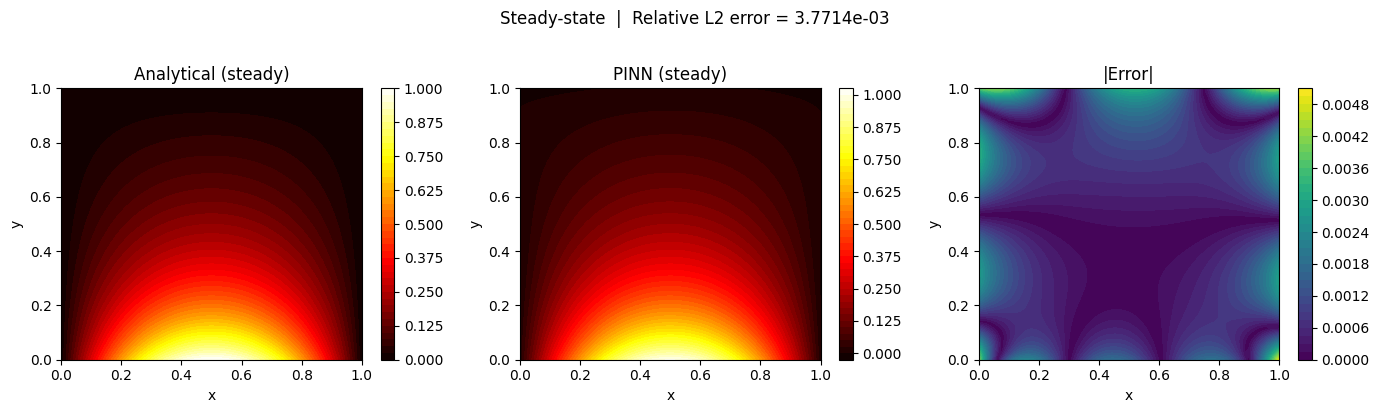

In [14]:
# ── Evaluation: steady-state ──────────────────────────────────────────────────
x1d = np.linspace(0, 1, 80)
y1d = np.linspace(0, 1, 80)
XX, YY = np.meshgrid(x1d, y1d)

u_true_ss = u_exact_steady(XX, YY)

x_t = torch.tensor(XX.ravel(), dtype=torch.float32)
y_t = torch.tensor(YY.ravel(), dtype=torch.float32)

model_ss.eval()
with torch.no_grad():
    u_pred_ss = model_ss(x_t, y_t).numpy().reshape(80, 80)
model_ss.train()

err_ss   = np.abs(u_pred_ss - u_true_ss)
rel_l2ss = np.linalg.norm(u_pred_ss - u_true_ss) / np.linalg.norm(u_true_ss)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title, cmap in zip(
    axes,
    [u_true_ss, u_pred_ss, err_ss],
    ['Analytical (steady)', 'PINN (steady)', '|Error|'],
    ['hot', 'hot', 'viridis'],
):
    im = ax.contourf(XX, YY, data, levels=40, cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'Steady-state  |  Relative L2 error = {rel_l2ss:.4e}', y=1.02)
plt.tight_layout()
plt.show()


---
## 12. Mixed Dirichlet–Neumann BCs (more interesting field)

### Why the all-Dirichlet field looks boring at the top

With $u=0$ on all walls, the solution $u = \sin(\pi x)\sinh(\pi(1-y))/\sinh(\pi)$ **decays to zero** at the top. The field looks like a stubby hill that just fades out.

### The 1D trap: uniform left=0, right=1, top/bottom Neumann

If you set:
- Left: $u=0$, Right: $u=1$ (uniform constants)
- Top and bottom: $\partial u/\partial y = 0$ (Neumann / insulated)

The solution is exactly $u(x,y) = x$ — purely 1D, no $y$-variation at all. The Neumann condition forces no heat flux through the top and bottom walls; since the left/right walls also impose no $y$-variation, the whole field ends up independent of $y$. **Neumann + constant Dirichlet → 1D.**

To keep it 2D you need $y$-variation somewhere.

### The interesting case: insulated top, hot bottom

| Wall | Condition | Type |
|---|---|---|
| Bottom ($y=0$) | $u = \sin(\pi x)$ | Dirichlet |
| Left ($x=0$) | $u = 0$ | Dirichlet |
| Right ($x=1$) | $u = 0$ | Dirichlet |
| Top ($y=1$) | $\partial u/\partial y = 0$ | **Neumann** |

The top wall is now **insulated** — no heat escapes there. The field has to reach a non-zero steady temperature at the top instead of being forced to zero.

### Analytical solution

Separation of variables with $Y'(1)=0$ gives cosine-hyperbolic (instead of hyperbolic sine):

$$\boxed{u(x,y) = \sin(\pi x)\,\frac{\cosh(\pi(1-y))}{\cosh(\pi)}}$$

**Verification:**
- $u_{xx} + u_{yy} = -\pi^2 u + \pi^2 u = 0$ ✓
- $u(x,0) = \sin(\pi x)\,\cosh(\pi)/\cosh(\pi) = \sin(\pi x)$ ✓  
- $u(0,y) = u(1,y) = 0$ ✓
- $\partial u/\partial y\big|_{y=1} = \sin(\pi x)\cdot(-\pi\sinh(0))/\cosh(\pi) = 0$ ✓

Compare $\cosh$ vs $\sinh$ at the top:
- All-Dirichlet: $\sinh(0)/\sinh(\pi) = 0$ — zero at top
- Mixed (insulated top): $\cosh(0)/\cosh(\pi) = 1/\cosh(\pi) \approx 0.086$ — non-zero plateau at top

### Neumann BC in the PINN loss

A Dirichlet loss just evaluates $\hat{u}$ and compares to a target — no gradients needed.  
A Neumann loss needs the **derivative of $\hat{u}$ with respect to the normal direction** at the boundary — which means another call to `torch.autograd.grad`.

For the top wall (outward normal = $+y$):

$$\mathcal{L}_\text{Neumann} = \frac{1}{N}\sum_i \left(\frac{\partial \hat{u}}{\partial y}(x_i, 1)\right)^2$$


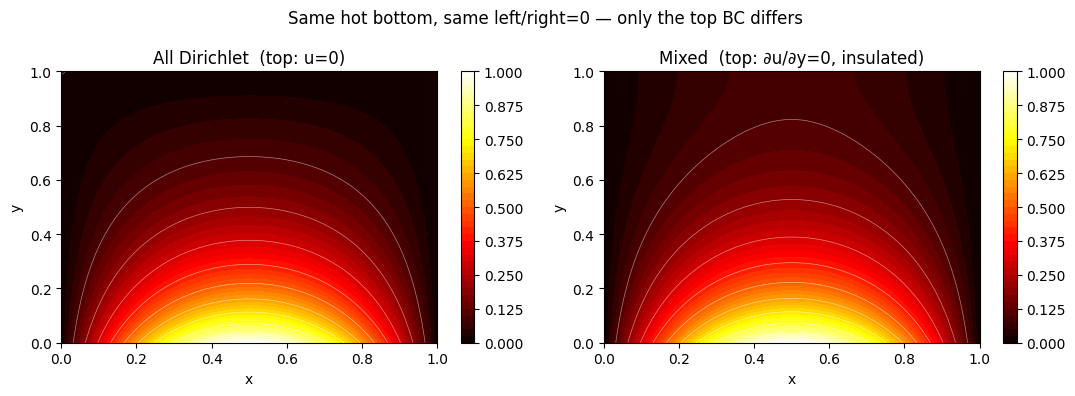

Value at top-centre (x=0.5, y=1):


TypeError: sin(): argument 'input' (position 1) must be Tensor, not float

In [15]:
def u_exact_mixed(x, y):
    """
    Analytical solution: bottom hot, left/right cold, top insulated (Neumann).
      u(x,y) = sin(pi*x) * cosh(pi*(1-y)) / cosh(pi)
    """
    if isinstance(x, np.ndarray):
        sin, cosh = np.sin, np.cosh
    else:
        sin, cosh = torch.sin, torch.cosh
    return sin(np.pi * x) * cosh(np.pi * (1 - y)) / np.cosh(np.pi)


# ── Side-by-side: all-Dirichlet vs mixed BCs ─────────────────────────────────
x1d = np.linspace(0, 1, 80)
y1d = np.linspace(0, 1, 80)
XX, YY = np.meshgrid(x1d, y1d)

U_dirichlet = u_exact_steady(XX, YY)   # sinh version (all walls cold)
U_mixed     = u_exact_mixed(XX, YY)    # cosh version (top insulated)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, U, title in zip(axes,
                        [U_dirichlet, U_mixed],
                        ['All Dirichlet  (top: u=0)', 'Mixed  (top: ∂u/∂y=0, insulated)']):
    im = ax.contourf(XX, YY, U, levels=40, cmap='hot', vmin=0)
    plt.colorbar(im, ax=ax)
    ax.contour(XX, YY, U, levels=10, colors='white', linewidths=0.5, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Same hot bottom, same left/right=0 — only the top BC differs')
plt.tight_layout()
plt.show()

print(f'Value at top-centre (x=0.5, y=1):')
print(f'  All-Dirichlet : {u_exact_steady(0.5, 1.0):.4f}  (forced to zero)')
print(f'  Mixed         : {u_exact_mixed(0.5, 1.0):.4f}  (non-zero plateau)')


In [16]:
def neumann_y_loss(model, x, y):
    """
    Enforce ∂u/∂y = 0 on a horizontal boundary.

    Unlike Dirichlet loss (which just evaluates the network), this needs
    autograd to compute the derivative of the output w.r.t. y.
    x can remain a plain tensor; only y needs requires_grad.
    """
    y = y.clone().requires_grad_(True)
    u = model(x, y)
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    return (u_y ** 2).mean()


# ── Samplers for mixed BC case ────────────────────────────────────────────────
def sample_dirichlet_mixed(n_per_edge):
    """Bottom (hot), left (cold), right (cold). Returns x, y, u_target."""
    n = n_per_edge
    # bottom: y=0, u=sin(pi*x)
    x_bot = torch.rand(n);  y_bot = torch.zeros(n)
    u_bot = torch.sin(torch.pi * x_bot)
    # left: x=0, u=0
    x_lft = torch.zeros(n); y_lft = torch.rand(n)
    u_lft = torch.zeros(n)
    # right: x=1, u=0
    x_rgt = torch.ones(n);  y_rgt = torch.rand(n)
    u_rgt = torch.zeros(n)

    x = torch.cat([x_bot, x_lft, x_rgt])
    y = torch.cat([y_bot, y_lft, y_rgt])
    u = torch.cat([u_bot, u_lft, u_rgt])
    return x, y, u


def sample_neumann_top(n):
    """Top wall: y=1, random x. For Neumann ∂u/∂y=0."""
    x = torch.rand(n)
    y = torch.ones(n)
    return x, y


# ── Train mixed-BC PINN ───────────────────────────────────────────────────────
W_NEU = 10.0   # Neumann weight — same order as Dirichlet weight

model_mix = PINN_SS(hidden=[64, 64, 64, 64])
opt_mix   = torch.optim.Adam(model_mix.parameters(), lr=1e-3)
sched_mix = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mix, T_max=8000, eta_min=1e-5)

history_mix = {'pde': [], 'dir': [], 'neu': [], 'total': []}

print('Training mixed BC PINN (bottom hot, top insulated)...')
for epoch in range(1, 8001):
    opt_mix.zero_grad()

    xf, yf           = sample_interior_ss(2000)
    xd, yd, ud       = sample_dirichlet_mixed(n_per_edge=200)
    xn, yn           = sample_neumann_top(n=200)

    l_pde = pde_loss_ss(model_mix, xf, yf)
    l_dir = bc_loss_ss(model_mix, xd, yd, ud)
    l_neu = neumann_y_loss(model_mix, xn, yn)

    loss = W_PDE_SS * l_pde + W_BC_SS * l_dir + W_NEU * l_neu
    loss.backward()
    opt_mix.step()
    sched_mix.step()

    history_mix['pde'].append(l_pde.item())
    history_mix['dir'].append(l_dir.item())
    history_mix['neu'].append(l_neu.item())
    history_mix['total'].append(loss.item())

    if epoch % 2000 == 0 or epoch == 1:
        print(f'  Epoch {epoch:5d} | pde={l_pde.item():.3e} | '
              f'dir={l_dir.item():.3e} | neu={l_neu.item():.3e}')

print('Done.')


Training mixed BC PINN (bottom hot, top insulated)...
  Epoch     1 | pde=6.607e-04 | dir=1.366e-01 | neu=3.567e-05
  Epoch  2000 | pde=3.253e-03 | dir=6.882e-05 | neu=5.189e-05
  Epoch  4000 | pde=1.574e-03 | dir=5.520e-06 | neu=1.188e-05
  Epoch  6000 | pde=7.749e-04 | dir=4.232e-06 | neu=3.605e-06
  Epoch  8000 | pde=5.922e-04 | dir=3.272e-06 | neu=2.517e-06
Done.


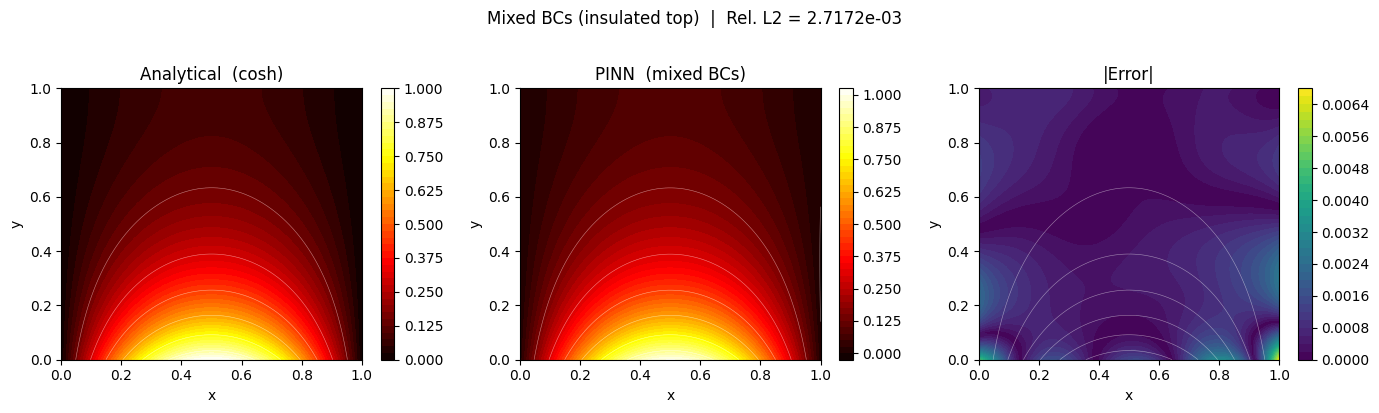

Relative L2 error vs analytical: 2.7172e-03

Neumann check — ∂u/∂y along top wall (should be ~0):
  max |∂u/∂y| = 3.0170e-03
  mean |∂u/∂y| = 1.3302e-03


In [17]:
# ── Evaluate mixed-BC PINN vs analytical ─────────────────────────────────────
x1d = np.linspace(0, 1, 80)
y1d = np.linspace(0, 1, 80)
XX, YY = np.meshgrid(x1d, y1d)

u_true_mix = u_exact_mixed(XX, YY)

x_t = torch.tensor(XX.ravel(), dtype=torch.float32)
y_t = torch.tensor(YY.ravel(), dtype=torch.float32)

model_mix.eval()
with torch.no_grad():
    u_pred_mix = model_mix(x_t, y_t).numpy().reshape(80, 80)
model_mix.train()

err_mix  = np.abs(u_pred_mix - u_true_mix)
rel_l2   = np.linalg.norm(u_pred_mix - u_true_mix) / np.linalg.norm(u_true_mix)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title, cmap in zip(
    axes,
    [u_true_mix, u_pred_mix, err_mix],
    ['Analytical  (cosh)', 'PINN  (mixed BCs)', '|Error|'],
    ['hot', 'hot', 'viridis'],
):
    im = ax.contourf(XX, YY, data, levels=40, cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.contour(XX, YY, data if cmap != 'viridis' else u_true_mix,
               levels=8, colors='white', linewidths=0.4, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'Mixed BCs (insulated top)  |  Rel. L2 = {rel_l2:.4e}', y=1.02)
plt.tight_layout()
plt.show()

# ── Check that top boundary gradient is near zero ────────────────────────────
x_top = torch.linspace(0, 1, 40)
y_top = torch.ones(40).requires_grad_(True)
u_top = model_mix(x_top, y_top)
u_top_y = torch.autograd.grad(u_top.sum(), y_top)[0]

print(f'Relative L2 error vs analytical: {rel_l2:.4e}')
print(f'\nNeumann check — ∂u/∂y along top wall (should be ~0):')
print(f'  max |∂u/∂y| = {u_top_y.abs().max().item():.4e}')
print(f'  mean |∂u/∂y| = {u_top_y.abs().mean().item():.4e}')
